In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.lines import Line2D
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import read_dataset, to_latex

plt.rcParams.update({'font.size': 26})
sns.set_style('ticks')

In [3]:
# 1s
df_x, df_y = read_dataset('original')

## Multicollinearity test using VIF

##### ℹ️ This notebook doesn't output any file

*np* and *ng* are strongly inversely correlated.

#### $$np\approx  -1.06\times ng + 165$$

Why "inversely"?

Think of the engine like a shared power source with two "users" — the rotor and the compressor:

When the rotor draws a lot of power (like adding load to an electric generator), there’s less left for the compressor. When the rotor draws little power, the compressor can "take more" of the engine's energy.

In [4]:
def calculate_vif(data):
    vif_df = data.assign(const=1)
    vif = []
    for i in range(vif_df.shape[1]):
        vif.append(variance_inflation_factor(vif_df.values, i))

    vif_data = pd.Series(vif, index=vif_df.columns)
    vif_data = vif_data[vif_data.index != "const"]
    fig, ax = plt.subplots(figsize=(22, 5))
    ax.fill_between([-0.5, len(vif_data) - 0.5], 0, 5, color="tab:blue", alpha=0.25)
    ax.fill_between([-0.5, len(vif_data) - 0.5], 5, 41, color="tab:red", alpha=0.25)
    sns.barplot(x=vif_data.index, y=vif_data, hue=vif_data, palette="inferno", legend=False, ax=ax)
    ax.add_line(Line2D([-0.5, len(vif_data) - 0.5], [5] * 2, linestyle="--", color="tab:blue", linewidth=2))
    ax.set_xticklabels(map(to_latex, vif_data.index), rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("VIF")
    return vif_data

/tmp/ipykernel_2149554/86893819.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(map(to_latex, vif_data.index), rotation=90)


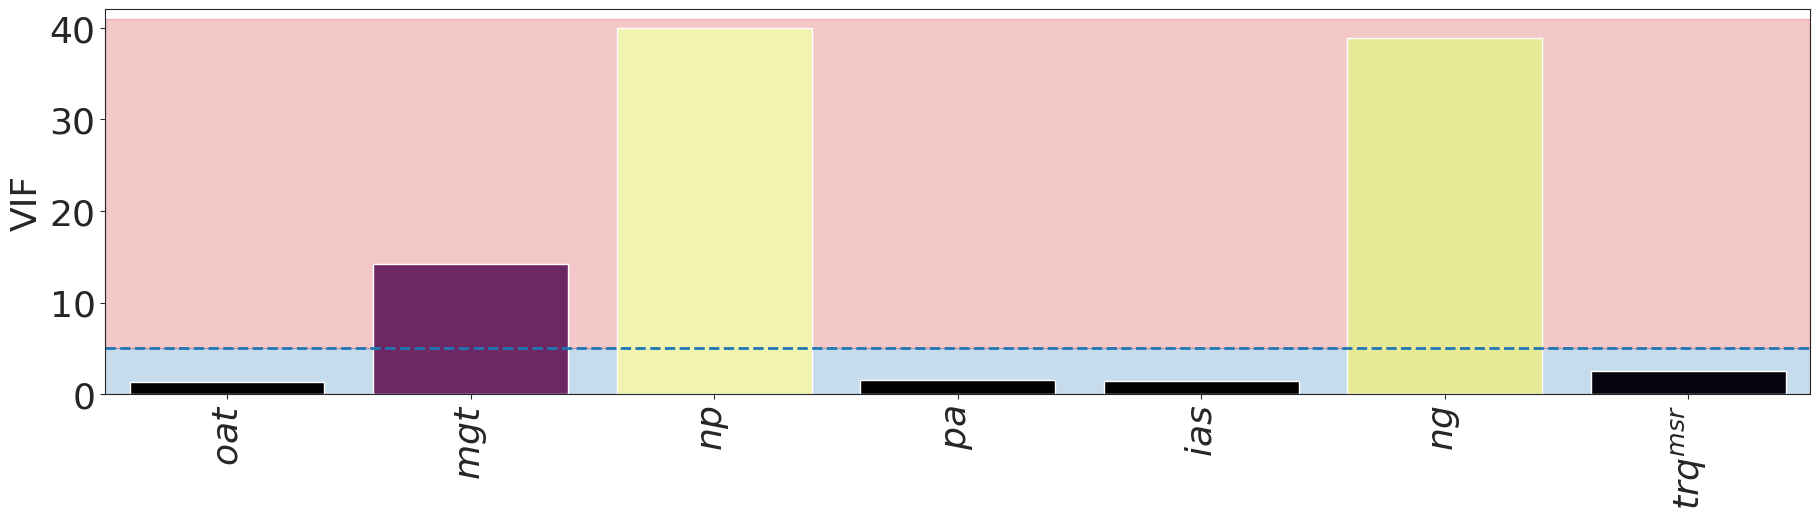

In [64]:
# 3s
vif_df = df_x[['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']]
vif_data = calculate_vif(vif_df)

Ok, there seems to be an interesting multicollinearity between the feature. What is the linear regressor that estimates np, with a good value of $R^2$?

In [6]:
# 0s
osl_x = vif_df.drop(columns=['np']).assign(const=1)
osl_y = df_x['np']
np_osl_model = sm.OLS(osl_y, osl_x).fit()
print(np_osl_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     np   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 4.831e+06
Date:                Mon, 28 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:39:22   Log-Likelihood:            -7.1261e+05
No. Observations:              742625   AIC:                         1.425e+06
Df Residuals:                  742618   BIC:                         1.425e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
oat             -0.0006      0.000     -5.867   

What a surprise! We can predict `np` from all the other features using a linear ressor having $R^2 =0.975$!

-0.7891654004519081

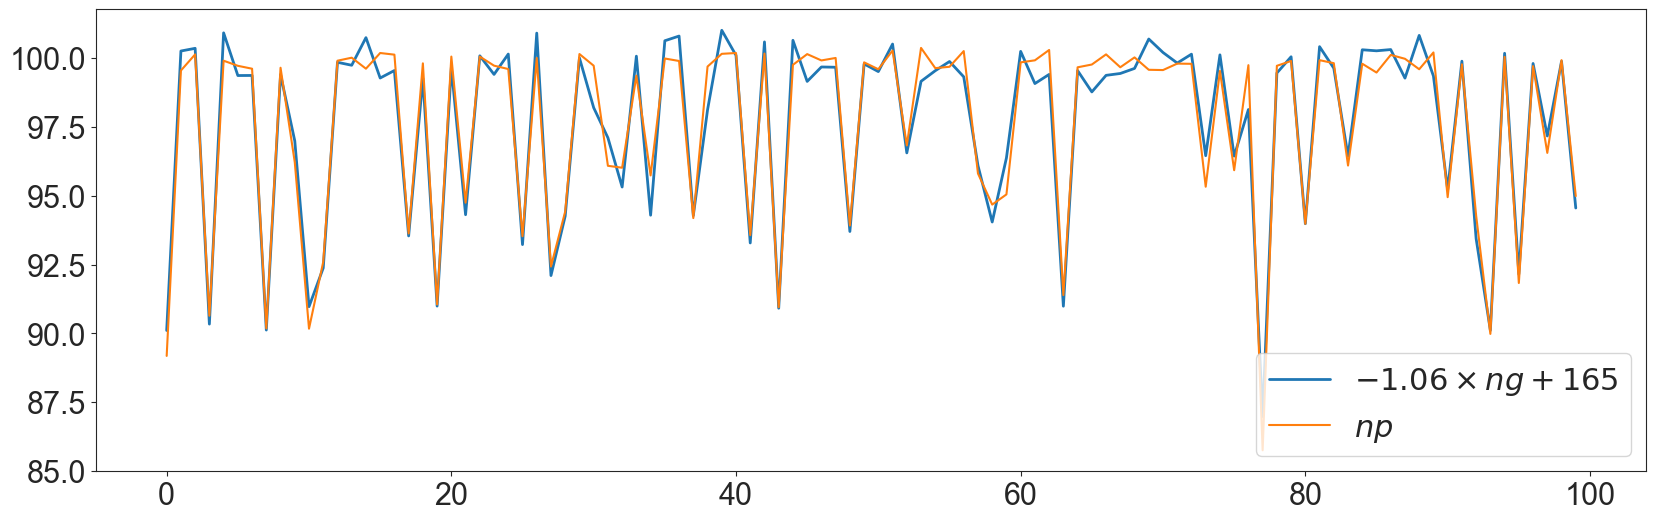

In [7]:
# 0s
ax = pd.Series(np_osl_model.predict()[:100]).plot(figsize=(20, 6), label='$-1.06\\times ng + 165$', linewidth=2)
(df_x['np'][:100]).plot(ax=ax, label='$np$')
ax.legend(loc='lower right')
df_x['ng'].corr(df_x['np'])

The prediction is very accurate.

The correlation between `np` and `ng` is only $-0.79$, which is not enough for a later pruning to remove one of them. In other words, without this multicollinearity study, *we would have ended up feeding our models with an almost irrelevant feature*.